# Analysis of Gender bias in British Political Media

## Introduction

Within British politics, we will examine two primary sources of commentary and communication: newspapers and social media. These two different sources serve different purposes but both are able to provide some form of insight into the role gender plays in the current political landscape. Much qualitative analysis has taken place on news and media and its interaction with gender, but recent advances in natural language processing provide a chance to develop broader analysis of a large dataset like never before. The data will be analysed to highlight any patterns or discrepancies between traditional media and social media's perspective and potential biases about women in the political landscape

## Data


For the task, two datasets have been chosen, due to their cardinality, accessibility and applicability to this task. The first dataset chosen was Kaggle's [Guardian News Articles](https://www.kaggle.com/datasets/adityakharosekar2/guardian-news-articles?resource=download). This dataset compiles approximately 150,000 news articles from this British newspaper, along with its corresponding metadata. It has been chosen due to its accessibility, as the Guardian is the only mainstream British newspaper without a paywall to its articles. 

The second dataset that was chosen was a second Kaggle dataset, [Global Political Tweets](https://www.kaggle.com/datasets/kaushiksuresh147/political-tweets), which compiles a global collection of tweets, all using the \#Politics hashtag, in order to self-label by topic but not by location. This dataset was chosen due to its accessibility and ease of use, but also is one of the most active platforms for political discourse and can be used to represent a wider range of users views, not just those of journalists.

## Data Exploration

In this section, we will explore the two datasets and its columns, rows, catergories and cardinality. This will also give us some insight into its limitations and what preprocessing might be required moving forwards. 

First we will load both `.csv` files into respective dataframes for easier processing and exploration.

In [ ]:
import pandas as pd

guardian_df = pd.read_csv('data/guardian_articles.csv')
tweets_df = pd.read_csv('data/Political_tweets.csv')

Now we have these two datasets, we will gain a few more insights into their size, scope and how they can be filtered. We will start by analysing the *Guardian News Articles*. 

In [ ]:
print(guardian_df.head())
print(guardian_df.info())
print(guardian_df.columns)

As you can see, the dataset contains a number of columns with varying datatypes:
| article_id | sectionName | webTitle | webUrl | bodyContent | webPublicationDate | id |
|------------|-------------|----------|--------|-------------|--------------------|----|

The `sectionName` column is the most important part at this point in the analysis. There are large ranges of sections, which can be treated as labels for the general topic of body text. As the Guardian is a British publication, we can guarantee these come from British perspectives. But, not all of the articles in this dataset are on politics and, as a result, we need to filter this dataframe further into just its political articles.

In [ ]:
political_filtered_guardian_df = guardian_df[guardian_df['sectionName'] == 'Politics']
print(political_filtered_guardian_df.info())

So now we can see we have 7074 articles to complete our analysis on, which is a very wide scope. That said, more work can be done to extend the dataset. As you can see with qualitative analysis, however, 12130 articles fall under the `sectionName` of `Opinion`. On greater analysis, many of these articles explore political themes but do not fall under the objective political section. 

It would be advantageous to add at least some of the `Opinion` articles to our corpus but this is hard to complete manually. These articles would add variety and greater subjectivity to the dataset due to the nature of opinion pieces and also, therefore highlight some more prejudices that don't appear in the initial filtered corpus. 

We will approach this using a Zero-shot pretrained classifier as, at early stages in this exploration, training our own models may be time consuming. First, we create the opinion dataframe:

In [ ]:
opinion_filtered_guardian_df = guardian_df[guardian_df['sectionName'] == 'Opinion']
print(opinion_filtered_guardian_df.info())

The we use a pretrained model, in this instance `facebook/bart-large-mnli` to ascribe two labels to each value in the dataset to confirm if political or not. It must be admitted that for an article to have political undertones, it needn't be strictly on politics but this is a good way to extend the dataset, even it it proves not 100% accurate.

In [ ]:
# install required packages for transformers + torch runtime
%pip install -q transformers torch

from transformers import pipeline

# create the zero-shot classifier pipeline
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")
labels = ["political", "not political"]

def classify_text(text):
    # guard against NaN / non-string values which cause the pipeline to error
    if not isinstance(text, str) or pd.isna(text) or len(text.strip()) == 0:
        return "not political"
    result = classifier(text, candidate_labels=labels)
    return result["labels"][0]  # highest confidence label

opinion_filtered_guardian_df['classification'] = opinion_filtered_guardian_df['bodyContent'].apply(classify_text)


Above, we have used a transformer model on the articles with the `sectionName` of `Opinion`. If their `bodyContent` element is classed as *political*, it will be filtered into a new dataframe and then appended to the existing corpus. First, we remove that additional classification column then append the two dataframes.

In [ ]:
opinion_filtered_guardian_df = opinion_filtered_guardian_df[opinion_filtered_guardian_df['classification'] == 'political']
opinion_filtered_guardian_df = opinion_filtered_guardian_df.drop(columns=['classification'])
print(len(opinion_filtered_guardian_df))



As you can see, the size of the Opinion subset of articles that are filtered for being political is BLANK and then the two subsets are combined into one corpus below. Now we have all of the data to be worked with. 

In [ ]:
#guardian_combined_corpus_df = pd.concat([political_filtered_guardian_df, opinion_filtered_guardian_df], ignore_index=True)
guardian_combined_corpus_df = political_filtered_guardian_df
print(len(guardian_combined_corpus_df))

Now move onto the next dataset, the Global Political Tweets. This dataset must be filtered but in a different way to the prior one. As mentioned, it is a compilation of tweets that have self-identified as political, using the #politics hashtag, but it is a global dataset and we only want the perspectives of British social media, hence we must filter by location. 

There are a number of ways in which the location is denoted in the `user_location` column of this catergory, such as "Surrey, UK" or just "UK" alone. As a result, we will implement pattern matching in order to filter by location and create a compilation of political tweets in the UK.

In [ ]:
tweets_df["user_location"] = tweets_df["user_location"].astype(str).str.strip()

# Pattern matches:
# - UK
# - U.K.
# - United Kingdom
# - South West UK
# - London, UK
pattern = r"\b(UK|United Kingdom|London|Scotland|South West UK|England)\b"

# Filter for UK-based users
filtered_df = tweets_df[tweets_df["user_location"].str.contains(pattern, case=False, na=False)]

print(f"Number of tweets from UK: {len(filtered_df)}")

As you can see, we now have two dataframes with workable data on British political perspectives and news in politics. Using this dataset, we will do some comparison going forward. Below, we compare:

* Time period over which the data was collected
* The average length of the text body which will be analyzed
* The size of each dataset


It is important to recognise that a large amount more preprocessing must be done moving forward but for the time being, these dataframes can be worked with.


## Statistical Analysis

Before investigating further using more complicated NLP and ML techniques, we can approach an exploration using basic frequency analysis. First, we will perform it on the Guardian Article dataset then on the tweets. First, we will define the key words we are looking for:

In [ ]:
male_terms = [
    "man", "men", "male", "boy", "he", "him", "his"
]

female_terms = [
    "woman", "women", "female", "girl", "she", "her", "hers"
]


Then we will iterate through every article and tokenize the words, then count the frequency of male and female words.

In [ ]:
!pip install regex
import re

def tokenize(text):
    return re.findall(r"\b\w+\b", text.lower())

from collections import Counter

def count_gender_terms(article):
    tokens = tokenize(article)
    counts = Counter(tokens)
    
    male_count = sum(counts[word] for word in male_terms)
    female_count = sum(counts[word] for word in female_terms)
    
    return male_count, female_count


In [ ]:
male_total = 0
female_total = 0
for i, article in enumerate(guardian_combined_corpus_df.head(100)['bodyContent']):
    male_count, female_count = count_gender_terms(article)
    male_total += male_count
    female_total += female_count

print(f"Total male mentions: {male_total}")
print(f"Total female mentions: {female_total}")

Then, we've evaluated it for each article, we want to plot the cumulative total and we find, based on this frequency analyis that there is a dramatic difference in frequencies between male and female words.

In [ ]:

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(['Male mentions', 'Female mentions'], [male_total, female_total])
plt.title('Cumulative Gender Mentions in Top 100 Articles')
plt.ylabel('Frequency')
plt.show()

This is a *dramatic* difference - almost by a factor of ten, that men are mentioned in political contexts than women. This is not necessarily a tried and true approach, it may not be 100% accurate and perhaps could be normalized by article or by politican. That said, this an interesting insight. 

## Named Entity Recognition

Beyond just traditional frequency analysis of gendered words, we may propose a more sophisticated approach using BERT transformer architechture  (Das & Paik, 2021). Prior approaches to gender tagging have been database reliant, however leveraging the context of data may prove more fruitful in gender identification. They propose a Bidirectional Cascading Transformer architechture. What we want is to perform named entity recognition within a text and being contextually aware. 

What we can do with this is the use these entity recognitions is:

* Identify statistical distribution of gender
* Analyse representation bias
* Compare distribution with topic modelling/framing analysis to see the intersection between gender and topics

In [ ]:
import gender_guesser.detector as gender
detector = gender.Detector()
# example usage:
def absolute_gender(name):
    result = detector.get_gender(name)
    if result in ("male", "mostly_male"):
        return "male"
    elif result in ("female", "mostly_female"):
        return "female"
    else:
        return "unknown"


Now we have a model, which admittedly isn't context aware, to build our gender distribution recogniser. We can use NER to process each text and annotate each person with a gender and then evaluate the distribution over the articles.  

Labour’s unknown
Vote Leave’s unknown
Kurtz unknown
Willard” Jenkin unknown
Vote Leave unknown
Labour unknown
Dundee West unknown
De Piero unknown
Murnaghan unknown
Vote Leave unknown
Juncker unknown
Tusk’s Poland unknown
Cameron’s unknown
Amersham unknown
Pat McFadden unknown
Dr Martens unknown
Portcullis House unknown
Pat Jennings unknown
Labour unknown
MPs unknown
Twitter unknown
Twitter troll unknown
Hull unknown
Juncker unknown
Birmingham Yardley unknown
Britons unknown
Osborne unknown
Chuka Umunna unknown
Vote Leave unknown
Durham unknown
Hammersmith unknown
Feldman unknown
Osborne unknown
Labour unknown
Canary Wharf unknown
Capita unknown
Calais unknown
Chuka Umunna unknown
Dublin III unknown
Apple The unknown
Bermuda unknown
Downing St unknown
Lady Joanna Shields unknown
’s unknown
Labour unknown
Lib Dems unknown
Calais unknown
Sometimes Dave unknown
Cayman Islanders unknown
Better Jeff unknown
Sadiq Khan unknown
Zac Goldsmith unknown
patsy unknown
Lib Dems unknown
Holyrood unk

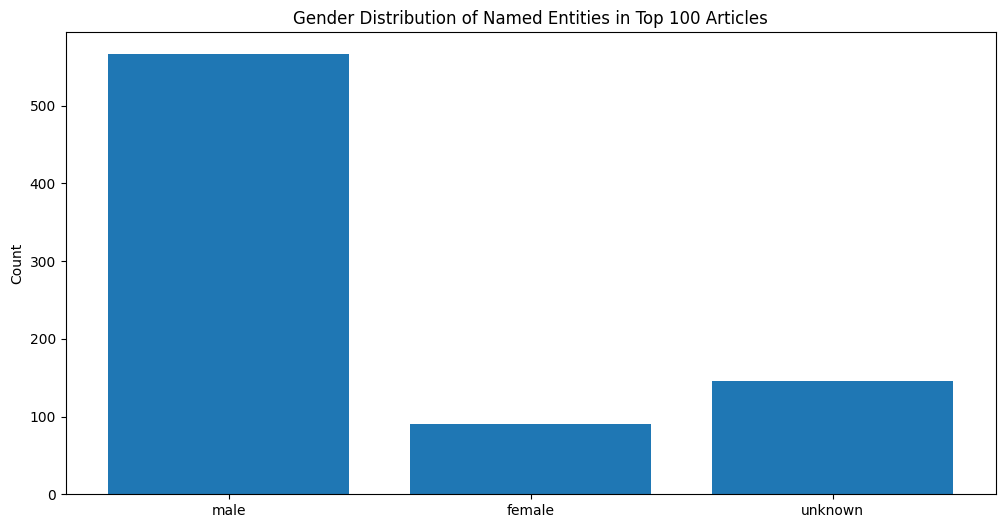

In [14]:
import pandas as pd
import spacy
import matplotlib.pyplot as plt
nlp = spacy.load("en_core_web_sm")
pd.set_option("display.max_rows", 200)

results = {'male': 0, 'female': 0, 'unknown': 0}

for i in range(100):
    content = str(guardian_combined_corpus_df.head(i+1)['bodyContent'].values[-1])
    doc = nlp(content)
    prev_names = set()
    
    for ent in doc.ents:
        if ent.label_ == "PERSON":
            name = ent.text.strip()

            
            # Use first name for gender detection
            first_name = name.split()[0]
            second_name = name.split()[1] if len(name.split()) > 1 else ""
            result = absolute_gender(first_name)
            if name in prev_names or second_name in prev_names:
                continue
            prev_names.add(name)
            prev_names.add(second_name)
            results[result] += 1
            
            if result == "unknown":
                print(name, result)

plt.figure(figsize=(12, 6))
plt.bar(results.keys(), results.values())
plt.title('Gender Distribution of Named Entities in Top 100 Articles')
plt.ylabel('Count')
plt.show()




The largest majority of unknown values can be filtered out from the NER mislabelling the entity as a person, when they are in fact a political party or organisation.

This approach gives some insight, but there are some failures, for instance, `Thatcher` is mentioned and treated as `Unknown` but we recognise that Thatcher refers to Margaret Thatcher. This can be due to existing biases in gender recognition (Mehrabi et al., 2019) and might be mitigated with more a list based approach in conjunction with the NER. There are a very large proportion of the named entities which are unknown. Whilst this is helpful for some, since it recognise non-person objects as people, it also can be explained by a potential misidentification of women.  

In [ ]:
# here we go through all the unknown names and reprocess against a list of MPs

Now we have a way to roughly recognise named entities and assign genders to them, answers the first question of representation bias. But this is just the start of the breakdown. We want to perform topic modelling and 

## Word Embeddings


Moving forward from the gender identification to the identification of more semantic attributes, we move to word embeddings. 

Word2Vec is a word embedding technique in natural language processing that allows words to be represented as vectors in continuous vector space and they can capture the semantic relationships between words. 

It uses two architectures:

* Continous Bag of Words (CBOW) - this model predicts the current word given context words. The input layer contains the context words and the output layer contains the current word. The hidden layer contains the dimensions we want to represent the current word present at the outer layer. 

* Skip Gram - this predicts the surrounding context words within specific window given current word. The input layer contains the current word and the output layer the context words. The hidden layer contains the number of dimensions in which we want to represent current word present at the input layer.

We will approach this task in a number of steps:

1. 

## Topic Modelling

Topic modelling find latent themes in a large collection of documents. It is a probability distribution over a fixed vocabulary (Ali & Hassan, 2022).  The latent Dirichlet allocation (LDA) topic model provides
an assignment of each document to the topic. The reason this is beneficial is this analysis can be coupled with NER gender classification to analyse the distribution of topics between genders. 


In [ ]:
# Install libraries if needed
!pip install gensim nltk

import nltk
nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from gensim import corpora
from gensim.models.ldamodel import LdaModel

# ---- Your article text ----
text = political_filtered_guardian_df.iloc[0]['bodyContent']

# ---- Preprocessing ----
stop_words = set(stopwords.words('english'))
tokens = word_tokenize(text.lower())
tokens = [t for t in tokens if t.isalpha() and t not in stop_words]

# Since LDA works on many documents, split into pseudo-docs (optional)
documents = [tokens]

# Build dictionary and corpus
dictionary = corpora.Dictionary(documents)
corpus = [dictionary.doc2bow(doc) for doc in documents]


lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=3, passes=15)

for idx, topic in lda_model.print_topics(num_words=5):
    print(f"Topic #{idx}: {topic}\n")

## References

Das, S., & Paik, J. H. (2021). Context-sensitive gender inference of named entities in text. Information Processing & Management, 58(1), 102423. https://doi.org/10.1016/j.ipm.2020.102423

‌Ali, M., & Hassan, N. (2022). A Survey of Computational Framing Analysis Approaches (pp. 9335–9348). https://aclanthology.org/2022.emnlp-main.633.pdf

‌Mehrabi, N., Gowda, T., Morstatter, F., Peng, N. and Galstyan, A. (2019). Man is to Person as Woman is to Location: Measuring Gender Bias in Named Entity Recognition. [online] arXiv.org. Available at: https://arxiv.org/abs/1910.10872 [Accessed 19 Nov. 2025].

‌